In [6]:
import pandas
import json

In [7]:
def jsonl_results_loader(save_path,num_records=500):
    """加载 JSONL 格式的结果文件"""
    results = []
    with open(save_path, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line.strip())
            results.append(record)
    return results[0:num_records]

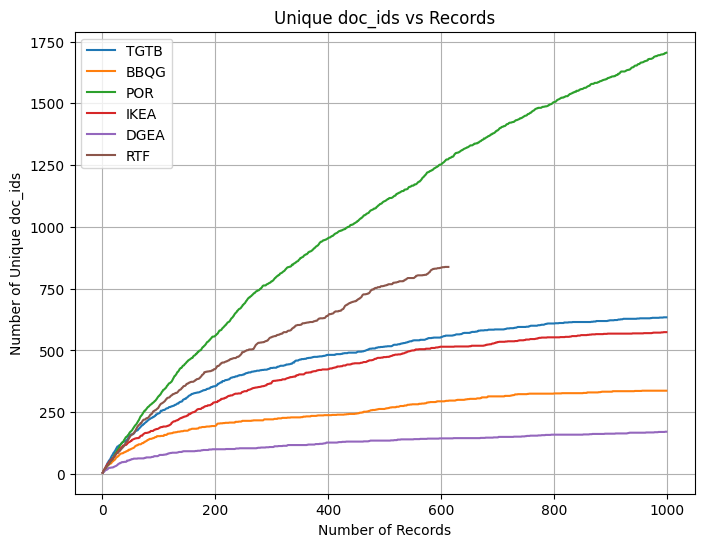

In [8]:
import matplotlib.pyplot as plt

# 1. 所有 save_path
save_paths = [
    "./results/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/TGTB_RW-0_RR-0_EX-0_IF-0_OF-0_tgtb_1000.jsonl",
    "./results/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/BBQG_RW-0_RR-0_EX-0_IF-0_OF-0_repeat_command_0_1000.jsonl",
    "./results/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/POR_RW-0_RR-0_EX-0_IF-0_OF-0_por_attack_1000.jsonl",
    "./results/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/IKEA_RW-0_RR-0_EX-0_IF-0_OF-0_repeat_command_0_1000.jsonl",
    "./results/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/DGEA_RW-0_RR-0_EX-0_IF-0_OF-0_dgea_attack_1000.jsonl",
    "./results/nfcorpus/qwen2_5-14b-instruct/R__bge-large-en-v1_5_k10-RR__bge-reranker-large_n5-EX__bge-large-en-v1_5/RTF_RW-0_RR-0_EX-0_IF-0_OF-0_rtf_attack_1000.jsonl" 
]

# 2. 对应的数据名称（用于图例）
labels = [
    "TGTB",
    "BBQG",
    "POR",
    "IKEA",
    "DGEA",
    "RTF"
]

assert len(save_paths) == len(labels), "save_paths 和 labels 长度必须一致"

plt.figure(figsize=(8, 6))

for save_path, label in zip(save_paths, labels):
    # 加载数据
    data_jsonl = jsonl_results_loader(save_path, 1000)

    doc_ids_list = [item['doc_ids'] for item in data_jsonl]

    # 计算 unique doc_ids 随 record 数量的变化
    chunk_num_list = []
    for i in range(1, len(doc_ids_list)):
        unique_doc_ids = set(
            doc_id
            for sublist in doc_ids_list[:i]
            for doc_id in sublist
        )
        chunk_num_list.append(len(unique_doc_ids))

    # 绘制
    plt.plot(
        range(1, len(doc_ids_list)),
        chunk_num_list,
        label=label
    )

# 3. 图形美化
plt.xlabel("Number of Records")
plt.ylabel("Number of Unique doc_ids")
plt.title("Unique doc_ids vs Records")
plt.legend()
plt.grid(True)

plt.show()